# Network And GCC

This notebook builds the RNA and protein GCC networks used downstream in topology, module, cross-modal, and survival analyses.

## Inputs

- RNA and protein CSD network edge tables from the network-construction step
- Harmonized RNA and protein expression matrices for healthy and cancer samples
- CPTAC clinical metadata used for downstream annotations

## Outputs

- `RNA_CSD_GCC.txt`
- `Protein_CSD_GCC.txt`
- Network summary tables, saved GCC figures, and homogeneity summaries

## Pipeline

1. Load the RNA and protein CSD networks together with the matching expression inputs.
2. Summarize the full CSD networks and inspect the giant connected components.
3. Optionally mirror the GCC networks in Cytoscape for interactive inspection.
4. Export GCC edge tables and summary outputs for downstream topology, module, cross-modal, and survival analyses.

## Setup




The first code cell imports shared network-analysis helpers from `Pipeline/4_Network_Analysis/utils/network_and_gcc.py`, then initializes `AnalysisContext` so the notebook can be rerun top-to-bottom with one consistent output directory.

In [4]:
import pandas as pd
from IPython.display import display

from utils import (
    build_analysis_context,
    configured_inputs_table,
    extract_gcc_cytoscape,
    extract_gcc_file,
    global_network_homogeneity,
    load_edges_clean,
    network_stats,
    open_in_cytoscape,
    validate_inputs,
 )

ctx = build_analysis_context(
    notebook_name='network_and_gcc',
    run_cytoscape=True,
    run_enrichment=False,
    save_figures=True,
 )

display(configured_inputs_table(ctx))
validate_inputs(ctx)
print('Inputs ready.')

,input,path,exists
0,RNA CSD network,C:\Users\tiril\Master-Tiril\results\CSD\CSDSel...,True
1,Protein CSD network,C:\Users\tiril\Master-Tiril\results\CSD\CSDSel...,True
2,RNA C network,C:\Users\tiril\Master-Tiril\results\CSD\CNetwo...,True
3,Protein C network,C:\Users\tiril\Master-Tiril\results\CSD\CNetwo...,True
4,RNA S network,C:\Users\tiril\Master-Tiril\results\CSD\SNetwo...,True
5,Protein S network,C:\Users\tiril\Master-Tiril\results\CSD\SNetwo...,True
6,RNA D network,C:\Users\tiril\Master-Tiril\results\CSD\DNetwo...,True
7,Protein D network,C:\Users\tiril\Master-Tiril\results\CSD\DNetwo...,True
8,RNA healthy expression,C:\Users\tiril\Master-Tiril\data\processed\tra...,True
9,RNA cancer expression,C:\Users\tiril\Master-Tiril\data\processed\tra...,True


All configured input files were found.
Inputs ready.


## Step 1: Summarize CSD networks

This step loads the configured RNA and protein CSD inputs, checks that the files are available, and builds the core summary objects used throughout the rest of the notebook.

In [10]:
network_jobs = [
    ('RNA_CSD', ctx.network_files['rna_csd']),
    ('Protein_CSD', ctx.network_files['prot_csd']),
]

network_summary = pd.DataFrame([network_stats(path, network_name=name) for name, path in network_jobs])
display(network_summary)

----------------------------------------
network: RNA_CSD
n_nodes: 1459
n_edges: 3093
n_components: 73
gcc_size: 1314
gcc_fraction: 0.9006168608636053
density: 0.0029080180629948355
avg_degree: 4.239890335846471
median_degree: 1.0
frac_c: 0.35240866472680243
frac_s: 0.30488199159392176
frac_d: 0.3427093436792758
----------------------------------------
network: Protein_CSD
n_nodes: 1068
n_edges: 3370
n_components: 18
gcc_size: 1034
gcc_fraction: 0.9681647940074907
density: 0.005914584276683199
avg_degree: 6.310861423220974
median_degree: 2.0
frac_c: 0.33501483679525224
frac_s: 0.3148367952522255
frac_d: 0.35014836795252224


,network,n_nodes,n_edges,n_components,gcc_size,gcc_fraction,density,avg_degree,median_degree,frac_c,frac_s,frac_d
0,RNA_CSD,1459,3093,73,1314,0.900617,0.002908,4.239890,1.0,0.352409,0.304882,0.342709
1,Protein_CSD,1068,3370,18,1034,0.968165,0.005915,6.310861,2.0,0.335015,0.314837,0.350148


## Step 2: Cytoscape (optional)

This step pushes the GCC networks to Cytoscape when interactive inspection is enabled in the shared analysis context.

In [11]:
if ctx.run_cytoscape:
    open_in_cytoscape(ctx.network_files['rna_csd'], 'RNA_CSD')
    open_in_cytoscape(ctx.network_files['prot_csd'], 'Protein_CSD')
    extract_gcc_cytoscape('RNA_CSD', 'RNA_CSD_GCC')
    extract_gcc_cytoscape('Protein_CSD', 'Protein_CSD_GCC')
else:
    print('Skipping Cytoscape import: ctx.run_cytoscape=False')

Skipping Cytoscape import: ctx.run_cytoscape=False


## Step 3: Save GCC tables

This step writes the RNA and protein GCC edge tables that are reused in the downstream topology, module, overlap, and survival notebooks.

In [12]:
gcc_jobs = [
    ('RNA', ctx.network_files['rna_csd'], ctx.output_path('RNA_CSD_GCC.txt')),
    ('Protein', ctx.network_files['prot_csd'], ctx.output_path('Protein_CSD_GCC.txt')),
]

gcc_summary_rows = []
for label, network_path, output_path in gcc_jobs:
    graph_gcc, edges_gcc = extract_gcc_file(network_path)
    cleaned_edges = load_edges_clean(edges_gcc, convert_symbols=True)
    cleaned_edges.to_csv(output_path, sep='	', index=False)
    stats = network_stats(cleaned_edges, network_name=f'{label}_CSD_GCC')
    stats['output_file'] = str(output_path)
    gcc_summary_rows.append(stats)

gcc_summary = pd.DataFrame(gcc_summary_rows)
display(gcc_summary)

----------------------------------------
network: RNA_CSD_GCC
n_nodes: 1314
n_edges: 3020
n_components: 1
gcc_size: 1314
gcc_fraction: 1.0
density: 0.003500876958085693
avg_degree: 4.596651445966515
median_degree: 2.0
frac_c: 0.3609271523178808
frac_s: 0.28841059602649005
frac_d: 0.35066225165562914
----------------------------------------
network: Protein_CSD_GCC
n_nodes: 1034
n_edges: 3353
n_components: 1
gcc_size: 1034
gcc_fraction: 1.0
density: 0.006278309032114309
avg_degree: 6.4854932301740815
median_degree: 2.0
frac_c: 0.33671339099314046
frac_s: 0.31166119892633465
frac_d: 0.3516254100805249


,network,n_nodes,n_edges,n_components,gcc_size,gcc_fraction,density,avg_degree,median_degree,frac_c,frac_s,frac_d,output_file
0,RNA_CSD_GCC,1314,3020,1,1314,1.0,0.003501,4.596651,2.0,0.360927,0.288411,0.350662,C:\Users\tiril\Master-Tiril\results\notebooks\...
1,Protein_CSD_GCC,1034,3353,1,1034,1.0,0.006278,6.485493,2.0,0.336713,0.311661,0.351625,C:\Users\tiril\Master-Tiril\results\notebooks\...


## Step 4: Homogeneity summary

This step computes and saves the global homogeneity summaries that capture the dominant C, S, and D composition in each GCC network.

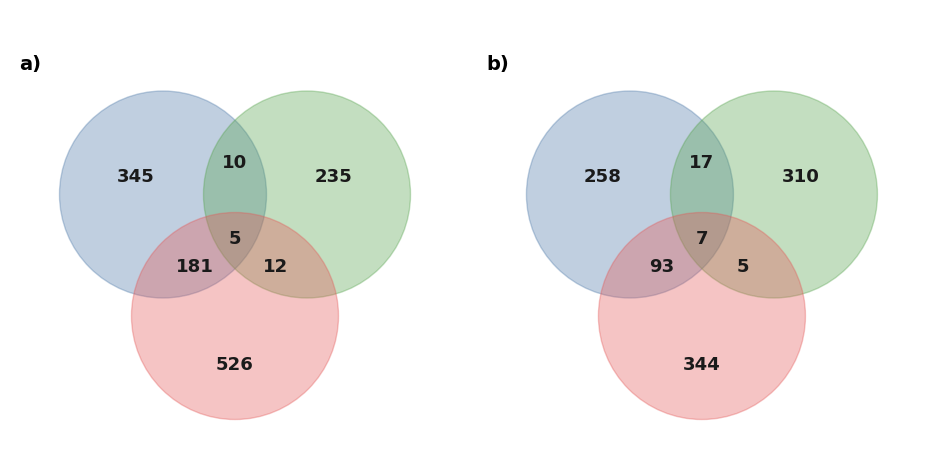

,network,C_only_genes,S_only_genes,D_only_genes,C_and_S_genes,C_and_D_genes,S_and_D_genes,C_and_S_and_D_genes
0,RNA,345,235,526,10,181,12,5
1,Protein,258,310,344,17,93,5,7


,network,n_nodes,pure_edge_type_nodes,mixed_edge_type_nodes,pure_edge_type_fraction,mixed_edge_type_fraction
0,RNA,1314,1106,208,0.841705,0.158295
1,Protein,1034,912,122,0.882012,0.117988


In [ ]:
import matplotlib.pyplot as plt

homogeneity_outputs = global_network_homogeneity(ctx)
display(homogeneity_outputs['figure'])
plt.close(homogeneity_outputs['figure'])
display(homogeneity_outputs['gene_homogeneity'])
print(f"Saved gene homogeneity counts to {ctx.output_path('gene_type_venn_counts.csv')}")
print(f"Saved node homogeneity summary to {ctx.output_path('node_edge_type_homogeneity_summary.csv')}")